## 1. Loading the Dataset and Initial Exploration

For this experiment, I'll be working with the Breast Cancer Wisconsin (Diagnostic) dataset. My first step is to load this dataset into a pandas DataFrame and get a quick overview of its structure.

In [1]:
import pandas as pd

# Define the column names as per the UCI dataset description
# This dataset does not have a header, so I need to provide the column names manually.
column_names = [
    'id',
    'diagnosis', # M = Malignant, B = Benign
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave_points_mean',
    'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se',
    'texture_se',
    'perimeter_se',
    'area_se',
    'smoothness_se',
    'compactness_se',
    'concavity_se',
    'concave_points_se',
    'symmetry_se',
    'fractal_dimension_se',
    'radius_worst',
    'texture_worst',
    'perimeter_worst',
    'area_worst',
    'smoothness_worst',
    'compactness_worst',
    'concavity_worst',
    'concave_points_worst',
    'symmetry_worst',
    'fractal_dimension_worst'
]

# Load the dataset
df = pd.read_csv('/content/wdbc.data', names=column_names)

# Display the first 5 rows of the DataFrame to confirm successful loading
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Dataset Overview

Now that I've loaded the data, I'll check its basic information, such as data types and non-null counts, and then get a statistical summary.

In [2]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Get descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 2. Data Preprocessing

Based on my initial exploration, I need to perform a couple of preprocessing steps:

1.  **Drop the 'id' column**: This column is just an identifier and doesn't contribute to the classification task.
2.  **Encode the 'diagnosis' column**: The target variable 'diagnosis' is categorical ('M' for Malignant, 'B' for Benign). I'll convert it into numerical format (e.g., 'M' = 1, 'B' = 0).

In [3]:
# Drop the 'id' column
df = df.drop('id', axis=1)

# Encode 'diagnosis' column: M = 1, B = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Display the first few rows after preprocessing to verify changes
print("First 5 rows after dropping 'id' and encoding 'diagnosis':")
display(df.head())

# Verify data types after encoding
print("\nDataFrame Info after preprocessing:")
df.info()

First 5 rows after dropping 'id' and encoding 'diagnosis':


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    fl

## 3. Splitting the Dataset into Training and Testing Sets

Before training any models, I'll split my dataset into features (X) and the target variable (y). The 'diagnosis' column is my target, and all other columns are features. Then, I'll divide these into training and testing sets to properly evaluate my models.

In [4]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of diagnosis in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of diagnosis in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)

Distribution of diagnosis in training set:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Distribution of diagnosis in test set:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 4. Training a Logistic Regression Classifier

I will now train a Logistic Regression model using the preprocessed training data. Logistic Regression is a linear model used for binary classification tasks, making it suitable for predicting whether a tumor is malignant or benign.

In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# I'll use a fixed random_state for reproducibility
# I'll also specify 'liblinear' solver which works well for small datasets and L1/L2 regularization
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5. Training a K Nearest Neighbors (KNN) Classifier

Next, I'll train a K Nearest Neighbors (KNN) classifier. This model classifies a data point based on the majority class among its 'k' nearest neighbors. I'll use `n_neighbors=5` as a starting point, which is a common choice, and a fixed `random_state` for reproducibility (though KNN itself isn't inherently random, some internal processes might be affected by it in certain implementations or when dealing with tie-breaking).

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
# I'll set n_neighbors to 5 and a random_state for consistency
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn_model.fit(X_train, y_train)

print("K Nearest Neighbors (KNN) classifier trained successfully.")

K Nearest Neighbors (KNN) classifier trained successfully.


## 6. Evaluating the Classifiers

Now that both models are trained, I will evaluate their performance on the test set. I'll calculate several key metrics: Accuracy, Precision, Recall, F1 Score, and display the Confusion Matrix for both Logistic Regression and KNN.

### 6.1. Evaluating Logistic Regression

Logistic Regression Performance:
Accuracy: 0.9386
Precision: 0.9730
Recall: 0.8571
F1 Score: 0.9114


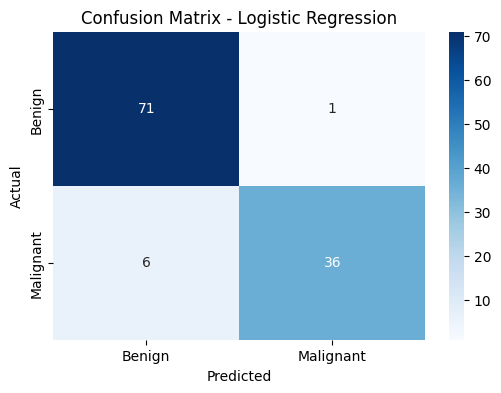

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set with Logistic Regression
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate evaluation metrics for Logistic Regression
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1 Score: {f1_log_reg:.4f}")

# Plot Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 6.2. Evaluating K Nearest Neighbors (KNN)

K Nearest Neighbors (KNN) Performance:
Accuracy: 0.9123
Precision: 0.9706
Recall: 0.7857
F1 Score: 0.8684


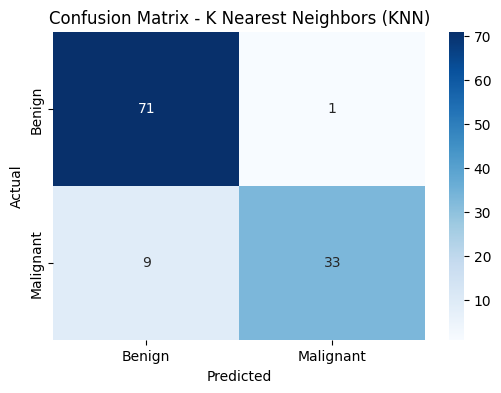

In [8]:
# Make predictions on the test set with KNN
y_pred_knn = knn_model.predict(X_test)

# Calculate evaluation metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("K Nearest Neighbors (KNN) Performance:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")

# Plot Confusion Matrix for KNN
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K Nearest Neighbors (KNN)')
plt.show()

## 7. Comparing Model Performance

I will now consolidate the evaluation metrics for both Logistic Regression and K Nearest Neighbors into a single comparison table to facilitate a clear understanding of their relative performance.

In [9]:
# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression', 'K Nearest Neighbors'],
    'Accuracy': [accuracy_log_reg, accuracy_knn],
    'Precision': [precision_log_reg, precision_knn],
    'Recall': [recall_log_reg, recall_knn],
    'F1 Score': [f1_log_reg, f1_knn]
}

# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df.round(4))


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9386,0.9730,0.8571,0.9114
1,K Nearest Neighbors,0.9123,0.9706,0.7857,0.8684


## 8. Interpretation of Results and Conclusion

Based on the comparison table and the evaluation metrics, I will now interpret the results and draw a conclusion about which classifier performed better for this particular dataset. I will consider all metrics to provide a comprehensive recommendation.